### Conformer

This notebook is only for showing the efficiency of Conformer structure, for function comments and other details, please refer to 04_conformer_transducer.ipynb. Please ignore the data preprocessing part as it is functionally identical to 02_datapreprocessing.ipynb.

### Initialize

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import math
from scipy.signal import stft
from typing import List, Tuple
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEBUG = True

In [ ]:
feature_dim = (0, None)
# clamp = (-2, 4) 
sample_idx = 0  

fs = 50  
nperseg = 64  
noverlap = 63  

stack_layers = 7

In [ ]:
def calculate_conv_output_shape(input_dim, kernel_size, stride, padding, dilation=1, return_rf=False):

    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(padding, int):
        padding = (padding, padding)
    if isinstance(dilation, int):
        dilation = (dilation, dilation)

    W_in = int(input_dim)
    K_h, K_w = kernel_size
    S_h, S_w = stride
    P_h, P_w = padding
    D_h, D_w = dilation

    W_out = (W_in + 2 * P_w - D_w * (K_w - 1) - 1) // S_w + 1

    rf = D_w * (K_w - 1) + 1
    jump = S_w

    if return_rf:
        return int(W_out), int(rf), int(jump)
    return int(W_out)


def calculate_receptive_field_for_layers(layers):

    rf = 1
    jump = 1
    for (kernel_size, stride, padding, dilation) in layers:

        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        if isinstance(stride, int):
            stride = (stride, stride)
        if isinstance(padding, int):
            padding = (padding, padding)
        if isinstance(dilation, int):
            dilation = (dilation, dilation)

        K_w = kernel_size[1]
        S_w = stride[1]
        D_w = dilation[1]

        rf = rf + (K_w - 1) * D_w * jump
        jump = jump * S_w

    return int(rf), int(jump)



conv1_shape = calculate_conv_output_shape(256, 3, 2, 1)
conv2_shape = calculate_conv_output_shape(conv1_shape, 3, 2, 1)

default1 = ( (3,3), (2,1), (0,0), (1,1) )
default2 = ( (3,3), (2,1), (0,0), (1,1) )
rf_total, total_jump = calculate_receptive_field_for_layers([default1, default2])

(conv2_shape, rf_total, total_jump)

(64, 5, 1)

In [ ]:
def conv_valid_length_multi(
    lengths: List[int],
    layers: List[Tuple[Tuple[int, ...], Tuple[int, ...], Tuple[int, ...], Tuple[int, ...]]]
) -> List[int]:

    out_lengths = lengths[:]
    for (kernel_size, stride, padding, dilation) in layers:
        new_lengths = []
        for L in out_lengths:
            k, s, p, d = kernel_size[0], stride[0], padding[0], dilation[0]
            L_out = math.floor((L + 2*p - d*(k - 1) - 1) / s) + 1
            new_lengths.append(max(L_out, 0))
        out_lengths = new_lengths
    return out_lengths

lengths = torch.tensor([160,150])  

layers = [
    [(3,1), (2,1), (1,0), (1,1)],  
    [(3,1), (2,1), (1,0), (1,1)],  
]

print(conv_valid_length_multi(lengths, layers))

[40, 38]


### Model

In [ ]:
# ----------- Positional Encoding -----------
class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=10000):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, dim, 2).float() * -(math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)   
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ----------- FeedForward -----------
class FeedForward(nn.Module):
    def __init__(self, dim, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * expansion),   
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * expansion, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# ----------- Convolution Module -----------
class ConvolutionModule(nn.Module):
    def __init__(self, dim, expansion_factor=2, kernel_size=31, dropout=0.1):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.pointwise_conv1 = nn.Conv1d(dim, dim * expansion_factor * 2, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        self.depthwise_conv = nn.Conv1d(dim * expansion_factor, dim * expansion_factor,
                                        kernel_size=kernel_size, padding=kernel_size // 2,
                                        groups=dim * expansion_factor)
        # self.batchnorm = nn.BatchNorm1d(dim * expansion_factor)
        self.swish = nn.SiLU()
        self.pointwise_conv2 = nn.Conv1d(dim * expansion_factor, dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, T, D]
        x = self.ln(x)
        x = x.transpose(1, 2)  
        x = self.pointwise_conv1(x)
        x = self.glu(x)
        x = self.depthwise_conv(x)
        # x = self.batchnorm(x)
        x = self.swish(x)
        x = self.pointwise_conv2(x)
        x = x.transpose(1, 2)  
        return self.dropout(x)

# ----------- Conformer Block -----------
class ConformerBlock(nn.Module):
    def __init__(self, dim, heads=8, ff_expansion=4, conv_expansion=2,   
                 conv_kernel_size=31, dropout=0.1):
        super().__init__()
        self.ffn1 = FeedForward(dim, ff_expansion, dropout)
        self.ffn2 = FeedForward(dim, ff_expansion, dropout)

        self.ln_attn = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.dropout_attn = nn.Dropout(dropout)

        self.conv = ConvolutionModule(dim, conv_expansion, conv_kernel_size, dropout)

        self.ln_out = nn.LayerNorm(dim)

    def forward(self, x, mask=None):        
        x = x + 0.5 * self.ffn1(x)

        x_norm = self.ln_attn(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, key_padding_mask=mask, need_weights=False)
        x = x + self.dropout_attn(attn_out)

        x = x + self.conv(x)

        x = x + 0.5 * self.ffn2(x)

        return self.ln_out(x)

# ----------- Conformer Encoder -----------
class ConformerEncoder(nn.Module):
    def __init__(self, dim, depth=6, heads=8, ff_expansion=4,       
                 conv_expansion=2, conv_kernel_size=31,
                 dropout=0.1, use_positional_encoding=True):
        super().__init__()
        self.use_pe = use_positional_encoding
        if self.use_pe:
            self.pos_encoding = PositionalEncoding(dim)

        self.layers = nn.ModuleList([
            ConformerBlock(dim, heads, ff_expansion, conv_expansion,
                           conv_kernel_size, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)

    def forward(self, x, mask=None):           
        if self.use_pe:
            x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, mask)

        return self.norm(x)



# ----------- Conv2D Subsampling Frontend -----------
class Conv2dSubsampling(nn.Module):
    DEFAULT_CONV_KWARGS = {
        "kernel_size": (7, 1),
        "stride": (2, 1),  
        "padding": (3, 3),
        "dilation": (1, 1)
    }

    DEFAULT_CONV_KWARGS_2 = {
        "kernel_size": (5, 1),
        "stride": (5, 1),  
        "padding": (2, 2),
        "dilation": (1, 1)
    }

    def __init__(self, in_dim, out_dim):   
        super().__init__()
        self.conv = nn.Sequential(      
            nn.Conv2d(in_dim, out_dim, **self.DEFAULT_CONV_KWARGS),  
            nn.ReLU(),
            nn.Conv2d(out_dim, out_dim, **self.DEFAULT_CONV_KWARGS_2),  
            nn.ReLU(),
        )
        conv1_shape = calculate_conv_output_shape(512, **self.DEFAULT_CONV_KWARGS)
        conv2_shape = calculate_conv_output_shape(conv1_shape, **self.DEFAULT_CONV_KWARGS_2)
        self.linear = nn.Linear(out_dim * conv2_shape, out_dim)  


    def forward(self, x, feat_lens):      
        x = x.transpose(2, 3)  
        x = self.conv(x)    
        b, d, t, f = x.size()    
        x = x.transpose(1, 2).contiguous().view(b, t, d * f)  
        x_lens = conv_valid_length_multi(feat_lens, [list(self.DEFAULT_CONV_KWARGS.values()), list(self.DEFAULT_CONV_KWARGS_2.values())])
        return self.linear(x), torch.tensor(x_lens)  


# ----------- Conformer-CTC Model -----------
class ConformerCTC(nn.Module):
    def __init__(self, input_dim, num_classes, encoder_dim, num_layers=6):
        super().__init__()
        self.subsampling = Conv2dSubsampling(input_dim, encoder_dim)
        self.encoder = ConformerEncoder(dim=encoder_dim, depth=num_layers, heads=4)  
        self.ctc_head = nn.Linear(encoder_dim, num_classes)

    def forward(self, x, feat_lens):
        x, x_lens = self.subsampling(x, feat_lens) 
        out = self.encoder(x)    
        logits = self.ctc_head(out)  

        return logits, x_lens


if __name__ == "__main__":
    B, C, F, T = 1, stack_layers, 512, 800  
    num_classes = 41  

    feats = torch.randn(B, C, F, T)
    feat_lens = torch.tensor([160, 20])  
    model = ConformerCTC(input_dim=C, encoder_dim=256, num_classes=num_classes)  

    logits, out_lens = model(feats, feat_lens)

### Load Data

In [ ]:
data_dir = "../data/hdf5_data_final"
folders = [os.path.join(data_dir, folder) for folder in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, folder))]

files = []
for folder in folders:
    files.extend([os.path.join(folder, file) for file in os.listdir(folder) if file == "data_train.hdf5"])
len(files)

45

In [ ]:
def process_features(x_np, fs=50, nperseg=64, noverlap=63, stack_layers=7):
    x = x_np.T
    C, T = x.shape
    stft_list = []
    for ch in range(C):
        f, t, Zxx = stft(x[ch], fs=fs, nperseg=nperseg, noverlap=noverlap)
        stft_list.append(np.abs(Zxx))  # (freq_bins, time_bins)
    stft_array = np.stack(stft_list, axis=0)  # (C, Freq, T_stft)
    stacked = np.stack(stft_array[:, 0:stack_layers, :], axis=0)  # (Freq, stack, T_stft)
    stft_stack = torch.from_numpy(stacked).float().permute(1, 0, 2)  # (stack, Freq, T_stft)
    return stft_stack.numpy().astype(np.float32)  

def save_all(data_root="../data/hdf5_data_final", out_root="../data/processed_hdf5"):
    os.makedirs(out_root, exist_ok=True)
    sessions = [d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))]  

    for sess in sessions:
        in_file = os.path.join(data_root, sess, "data_train.hdf5")
        if not os.path.exists(in_file):
            continue
        out_dir = os.path.join(out_root, sess)
        os.makedirs(out_dir, exist_ok=True)
        out_file = os.path.join(out_dir, "data_train_processed.hdf5")
        if os.path.exists(out_file):
            print(f"Skip existing {out_file}")
            continue

        with h5py.File(in_file, "r") as fin, h5py.File(out_file, "w") as fout:
            keys = list(fin.keys())
            for k in keys:
                g_in = fin[k]
                x = g_in["input_features"][:]         # (T, F)
                x_proc = process_features(x)          
                grp = fout.create_group(k)
                grp.create_dataset("input_features", data=g_in['input_features'], dtype="float32", compression="lzf")
                ds = grp.create_dataset(
                    "time_freq_features",
                    data=torch.tensor(x_proc),
                    dtype="float32",
                    compression="lzf",
                    chunks=(min(x_proc.shape[0], 4), x_proc.shape[1], min(x_proc.shape[2], 128)),
                )
                grp.create_dataset("seq_class_ids", data=g_in["seq_class_ids"], dtype="int32", compression="lzf")
                grp.attrs["seq_len"] = g_in.attrs["seq_len"] if 'seq_len' in g_in.attrs else None
                grp.attrs["n_time_steps"] = g_in.attrs["n_time_steps"]
                grp.attrs['sentence_label'] = g_in.attrs['sentence_label'][:] if 'sentence_label' in g_in.attrs else None
                grp.attrs['session'] = g_in.attrs['session']
                grp.attrs['block_num'] = g_in.attrs['block_num']
                grp.attrs['trial_num'] = g_in.attrs['trial_num']
        print(f"Saved {out_file}")
    
# save_all()

In [ ]:
class ProcessedH5Dataset(Dataset):
    def __init__(self, processed_files):
        self.files = processed_files
        self.index = []
        # 构建索引映射
        for file_idx, file_path in enumerate(processed_files):
            with h5py.File(file_path, 'r') as f:
                for sample_idx, key in enumerate(f.keys()):
                    g = f[key]
                    n_time_steps = g.attrs.get("n_time_steps", 0)  
                    self.index.append((file_idx, key, n_time_steps))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        fi, key, lenth = self.index[idx]
        fp = self.files[fi]
        with h5py.File(fp, "r") as f:
            g = f[key]
            feats = torch.tensor(g["input_features"][:])  # (C_proc, Freq, T_stft) or你定义的形状
            time_freq_features = torch.tensor(g["time_freq_features"][:])
            n_time_steps = torch.tensor(g.attrs["n_time_steps"])
            seq_class_ids = torch.tensor(g["seq_class_ids"][:])
            seq_len = torch.tensor(g.attrs["seq_len"])
            sentence_label = g.attrs["sentence_label"]

        return time_freq_features, n_time_steps, seq_class_ids[:seq_len], seq_len


root = "../data/processed_hdf5"
processed_files = []
for sess in os.listdir(root):
    fp = os.path.join(root, sess, "data_train_processed.hdf5")
    if os.path.exists(fp):
        processed_files.append(fp)
    
print('processed_files:', len(processed_files))
dataset =  ProcessedH5Dataset(processed_files)

processed_files: 45


In [ ]:
with h5py.File('../data/processed_hdf5/t15.2023.08.11/data_train_processed.hdf5', "r") as f:
    # print(f.keys())
    g = f['trial_0001']

    feats = g["time_freq_features"]  
    print(feats.shape)
    print(g['input_features'][:].shape)
    print(g["seq_class_ids"][:g.attrs["seq_len"]].shape)
    print(g.attrs["seq_len"])
    print(g.attrs['sentence_label'])
    print(g.attrs['n_time_steps'])

(7, 512, 482)
(481, 512)
(19,)
19
My family is closer.
481


In [18]:
dataset[0][2]

tensor([ 7, 28, 17, 24, 40, 17, 31, 40, 20, 21, 25, 29, 12, 40],
       dtype=torch.int32)

In [ ]:
def collate_fn(batch):    
    encoder_inputs, input_len, decoder_inputs, target_len = zip(*batch)  
    print(1)
    padded_encoder_inputs = torch.nn.utils.rnn.pad_sequence(encoder_inputs, batch_first=True, padding_value=0.0)
    padded_decoder_inputs = torch.nn.utils.rnn.pad_sequence(decoder_inputs, batch_first=True, padding_value=0)
    return padded_encoder_inputs, torch.tensor(input_len), padded_decoder_inputs, torch.tensor(target_len)  

batch_size = 1
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

batch = next(iter(dataloader))
padded_encoder_inputs, input_len, padded_decoder_inputs, target_len = batch
print(padded_encoder_inputs.shape, padded_decoder_inputs.shape)
input_len, target_len

torch.Size([1, 7, 512, 322]) torch.Size([1, 14])


(tensor([321]), tensor([14]))

### Train

In [ ]:
num_layers = 6
num_classes = 41
feat_dim = 512  
temperature = 3 
encoder_dim = 256

model = ConformerCTC(input_dim=stack_layers, encoder_dim = encoder_dim, num_classes=num_classes, num_layers = num_layers).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)

In [ ]:
epochs = 1
for e in range(epochs):
    for idx, (padded_encoder_inputs, input_len, padded_decoder_inputs, target_len) in enumerate(dataloader):
        optimizer.zero_grad()
        padded_encoder_inputs = padded_encoder_inputs.to(DEVICE)# .permute(0, 2, 1)  # [B, T, F] -> [B, F, T]
        padded_decoder_inputs = padded_decoder_inputs.to(DEVICE)
        input_len = input_len.to(DEVICE)    
        target_len = target_len.to(DEVICE)

        logits, out_lens = model(padded_encoder_inputs, input_len)   
        
        logits = logits.permute(1, 0, 2)  

        logits_len = torch.tensor(logits.shape[0]).to(DEVICE)   
        loss = ctc_loss_fn((logits / temperature).log_softmax(2), padded_decoder_inputs, logits_len, target_len)
        loss.backward()
        optimizer.step()
        print(e, idx, loss.item())

0 0 6.810057163238525
0 1 6.110665321350098
0 2 6.85854959487915
0 3 6.258430480957031
0 4 5.2730817794799805
0 5 5.134796619415283
0 6 4.482818603515625
0 7 4.100761413574219
0 8 5.719093322753906
0 9 5.672247886657715
0 10 4.268946647644043
0 11 4.367190361022949
0 12 6.9358696937561035
0 13 4.782846450805664
0 14 5.180659770965576
0 15 4.7196760177612305
0 16 5.905620574951172
0 17 4.478461265563965
0 18 4.696594715118408
0 19 4.330376625061035
0 20 4.0551371574401855
0 21 4.514718532562256
0 22 4.389186859130859
0 23 4.168615818023682
0 24 4.9038987159729
0 25 4.190873622894287
0 26 4.3007354736328125
0 27 4.017568111419678
0 28 4.077577114105225
0 29 5.85914421081543
0 30 4.901391983032227
0 31 4.241275787353516
0 32 6.116792678833008
0 33 4.371641635894775
0 34 4.064241409301758
0 35 4.0822577476501465
0 36 4.159918308258057
0 37 3.85760498046875
0 38 4.09576416015625
0 39 3.864664316177368
0 40 4.171487808227539
0 41 4.881283760070801
0 42 4.454899311065674
0 43 4.46111059188842

KeyboardInterrupt: 

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 44928297
Trainable parameters: 44928297


In [24]:
dataset[sample_idx][1].unsqueeze(0)

tensor([321])

In [ ]:
sample_idx = 5000
X = dataset[sample_idx][0].unsqueeze(0).to(DEVICE)  # (1, C, F, T)
print(X.shape)  # (C, F, T)

logits, logtis_shape = model(X, dataset[sample_idx][1].unsqueeze(0).to(DEVICE))
print('logits.shape:', logits.shape)

predicted_classes = torch.argmax(logits, dim=-1)
target = dataset[sample_idx][2]
print('dataset[sample_idx][0].shape:\n',
      dataset[sample_idx][0].shape,'\n',
      'predicted_classes:\n',
      predicted_classes,'\n', 
      'target:','\n',
      target, '\n',
      'target.shape:\n',
      target.shape)

torch.Size([1, 7, 512, 1028])
logits.shape: torch.Size([1, 103, 41])
dataset[sample_idx][0].shape:
 torch.Size([7, 512, 1028]) 
 predicted_classes:
 tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6,  6,  0,  0, 40, 40, 40,
         40, 40, 40, 40, 16, 25, 27, 27, 40, 40, 40, 40, 40, 40, 40, 40, 40, 37,
         37, 34,  0,  0, 40, 40, 40, 40, 40, 40, 40, 14, 36, 17, 28,  0, 40, 40,
         40, 40, 40, 40, 40, 40, 40, 20, 20,  3, 22, 22, 40, 40, 40, 40, 40, 40,
         40, 40, 40, 25, 25, 22,  0, 40, 40, 40, 40, 40, 40, 40, 40, 23, 18,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 40, 40, 40]], device='cuda:0') 
 target: 
 tensor([ 6, 40, 16, 25, 27, 40, 37, 34, 40, 36, 17, 21, 40, 20,  3, 22, 40, 16,
        25, 22, 40, 29, 34, 23, 40], dtype=torch.int32) 
 target.shape:
 torch.Size([25])


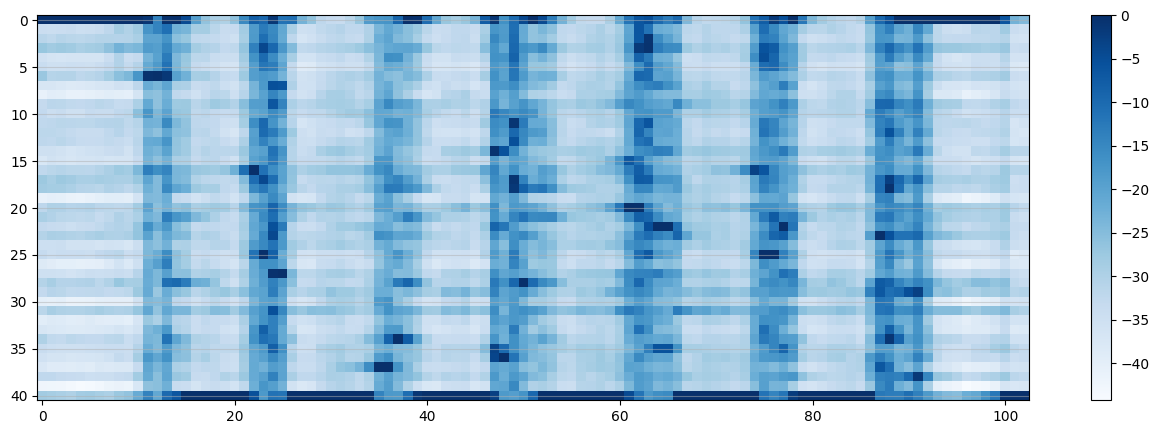

In [31]:
plt.figure(figsize=(16, 5))
# plt.imshow(logits.log_softmax(2).detach().cpu()[:,3,:].T, aspect='auto', cmap='Blues', interpolation='none')
plt.imshow(logits.log_softmax(2).detach().cpu()[0].T, aspect='auto', cmap='Blues', interpolation='none')
plt.colorbar()
# plt.yticks(np.arange(len(LOGIT_PHONE_DEF)), LOGIT_PHONE_DEF, fontsize=8)
plt.grid(axis='y', alpha=0.5)
# plt.title(f'Post-implant day {dat["post_implant_day"][trl]}, cue: "{dat["cue_sentence"][trl]}"')
plt.show()

### Save Model

In [ ]:
torch.save(model.state_dict(), "model_weights_kernel_size_15_temp_3_batch_1_stride_2_4.pth")
torch.save(model, "model_full_kernel_size_15_temp_3_batch_1_stride_2_4.pth")